# Volcano Plots
# Phase 2 vs. Phase 2

using results from [deseq_p2.v.p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_p2.v.p2.ipynb) to generate publication-formatted volcano plots

## 0. load libraries

In [2]:
library(tidyverse) # for ggplot and dplyr
library(cowplot) # for combining plots

## 1. Load CSVs


From looking at differnet comparisons, the DESeq analysis resulted in 36 output files. These contain *all genes*. Here, I start by assigning directionality for genes and write CSVs that contain only DEGs.

In [3]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bh_ch.csv"

The order of oyster treatment is intential - the oyster listed second is the 'baseline' from DESeq. In other words, If the file name is bb_cc.csv, then the LFC values are for BB in relation to CC (a +lfc = more expression in BB, a -lfc = more expression in CC)

I want to read in a csv, assign directionality to DEGs (or mark genes as not significant)

In [4]:
# create function
deg_list <- lapply(files, function(f) {

    # read file
  df <- read.csv(f)

    # get basename of file without extension (so just bb_cc if bb_cc.csv
  name <- tools::file_path_sans_ext(basename(f))
    # separate the two treatments (bb and cc)
  groups <- strsplit(name, "_")[[1]]
    # assign treatment names to variables
  g1 <- toupper(groups[1]) # BB
  g2 <- toupper(groups[2]) # CC

    # add comparison column
    df$pair <- paste(g2, 'vs.', g1)

  # set default for new col to NS (not significant)
  df$DEG_group <- "NS"

  # upregulated DEGs
  df$DEG_group[df$padj < 0.05 & df$log2FoldChange >  1] <- g1 # bb if cc is baseline

  # downregulated DEGs
  df$DEG_group[df$padj < 0.05 & df$log2FoldChange < -1] <- g2 

  df
})


In [5]:
# name list elements after the files
names(deg_list) <- tools::file_path_sans_ext(basename(files))

# basename() removes directory path, keeps only the filename
# tools::file_path_sans_exta(...) removes the file extension (.csv)
# names(deg_list) assigns those filenames as the names of the list elements
# now can access elements by name

writing out *only* DEGs for downstream analysis

In [8]:
out_dir <- "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/DEGs"  

for (nm in names(deg_list)) {

  df <- deg_list[[nm]]

  deg_df <- df[!is.na(df$DEG_group) & df$DEG_group != "NS", ]

  write.csv(
    deg_df,
    file = file.path(out_dir, paste0("DEG_", nm, ".csv")),
    row.names = FALSE
  )
}


## 2. using `ggplot` to make volcano plots

#### 1. single exposure experienced early in life affects GE
- CC vs. WC
- CC vs. HC
- CC vs. BC

In [9]:
# combining dfs
comp1 <- rbind(deg_list$wc_cc, deg_list$hc_cc, deg_list$bc_cc)

# check things look okay
head(comp1)
tail(comp1)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,1.973312e+03,-1.170306e-04,0.006495679,-0.70965886,0.4779157,1,0.9950360,2495.69160,2092.46282,⋯,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527,CC vs. WC,NS
2,LOC144621269,2.477696e+03,-1.754760e-03,0.075757798,-1.33665900,0.1813340,1,0.9713552,52.27077,1648.11743,⋯,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403,CC vs. WC,NS
3,LOC111120925,1.301645e+02,-2.433917e-05,0.032054869,-0.03983761,0.9682226,1,0.9897548,66.52643,23.22715,⋯,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321,CC vs. WC,NS
4,Trnae-cuc-2,1.043799e-02,0.000000e+00,0.297368391,0.00000000,1.0000000,1,0.9631260,0.00000,0.00000,⋯,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,CC vs. WC,NS
5,Trnae-cuc-3,3.559860e-02,-2.127649e-03,0.304059976,-0.19355140,0.8465272,1,0.9519494,0.00000,0.00000,⋯,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,CC vs. WC,NS
6,LOC144621283,8.712697e+02,-5.164538e-05,0.006245481,-0.29949006,0.7645662,1,0.9954676,540.76486,870.51301,⋯,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524,CC vs. WC,NS


,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
87052,LOC111111213,11075.926433,1.658625e-04,0.006911610,0.8149025,0.415128131,1.0000000,0.9907459,11318.046933,9510.001136,⋯,13068.8259,7538.652,8573.462642,9327.9104,11735.12197,8842.716365,7014.32652,9198.50056,CC vs. BC,NS
87053,LOC111114497,184.293713,-1.358869e-05,0.008488274,-0.0795226,0.936616955,1.0000000,0.9884813,100.740026,120.175229,⋯,317.9308,115.823,50.481625,162.7459,236.60455,68.875429,118.90538,119.27962,CC vs. BC,NS
87054,LOC111114498,2778.215373,-1.593858e-04,0.006534102,-0.7123962,0.476219443,1.0000000,0.9914942,2457.676494,2850.879602,⋯,2709.2691,2059.414,2214.647585,2758.1149,3021.34737,2202.902833,2348.65397,2513.46879,CC vs. BC,NS
87055,LOC111112304,1110.683329,-1.343205e-04,0.006510923,-0.6175583,0.536866561,1.0000000,0.9914549,1218.384093,1188.623908,⋯,683.2395,1128.766,1080.680712,1278.4120,868.70986,878.717166,1363.59380,1162.70766,CC vs. BC,NS
87056,LOC144621306,9.898835,-1.031214e-03,0.060176653,-0.6667888,0.504907041,1.0000000,0.9710647,7.603021,28.276525,⋯,19.9486,0.000,2.804535,0.0000,15.07774,0.000000,0.00000,0.00000,CC vs. BC,NS
87057,LOC144621888,34.079249,-3.623155e-02,0.334050638,-2.5801083,0.009876933,0.4961819,0.6900507,3.801510,7.069131,⋯,9.9743,0.000,329.065407,250.5430,55.67166,7.776258,22.90838,19.34264,CC vs. BC,NS


Warning message:
“Removed 1363 rows containing missing values or values outside the scale range
(`geom_point()`).”


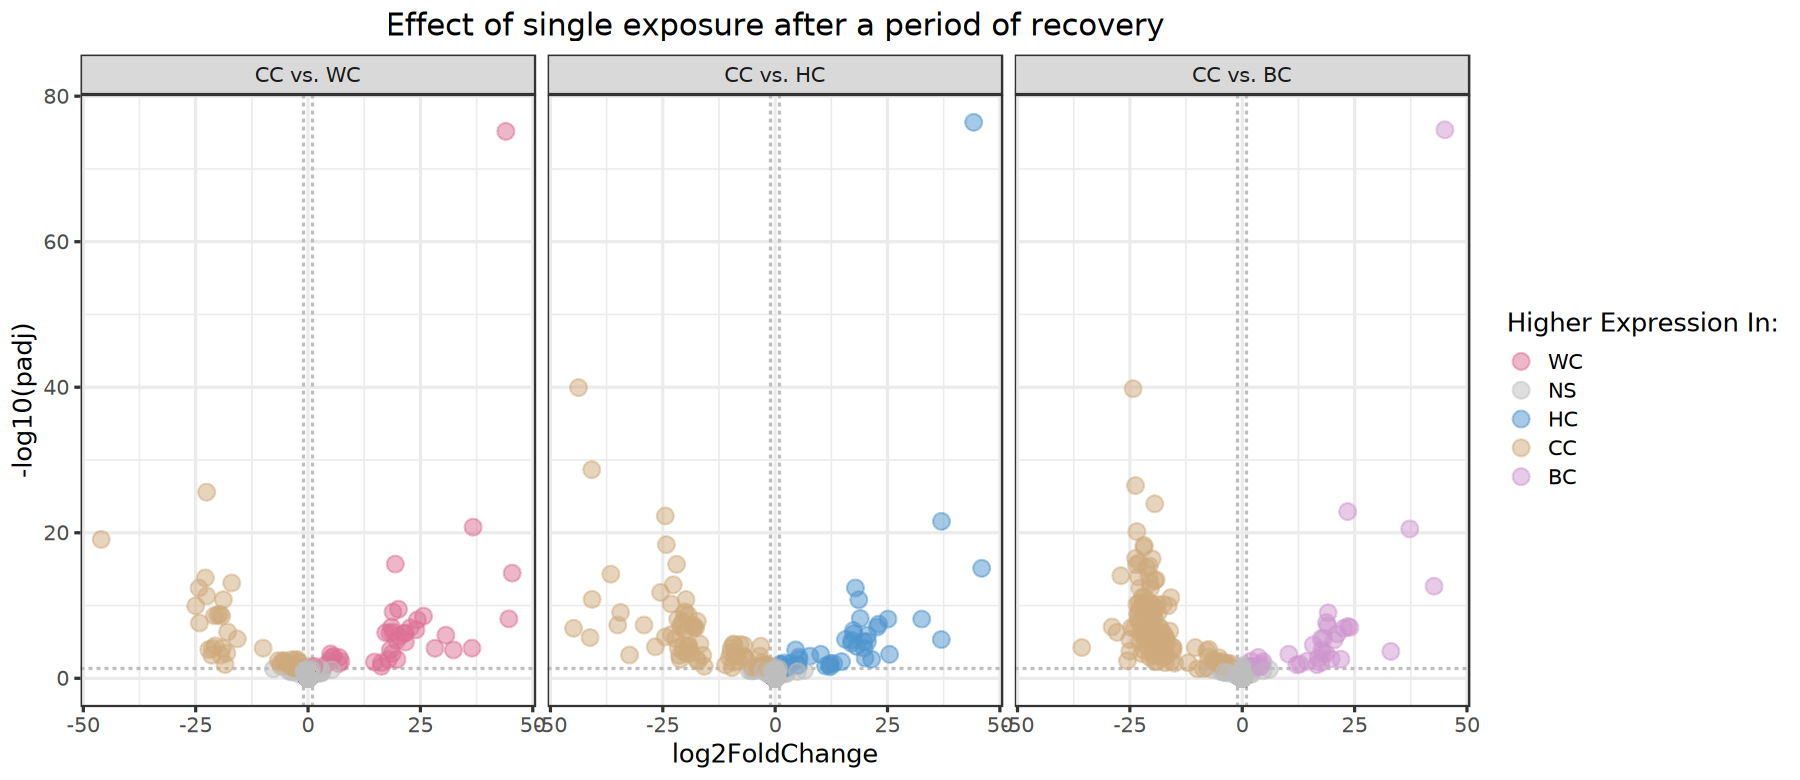

In [11]:
options(repr.plot.width=15, repr.plot.height=6.5)

# Specify the order for plots to follow Sophie's order
comp1$pair <- factor(comp1$pair, levels = c("CC vs. WC", "CC vs. HC", "CC vs. BC"))


comp1.plot <- ggplot(data = comp1,
                     aes(x = log2FoldChange,
                         y = -log10(padj),
                         col = DEG_group)) +
# fold change threshold line
geom_vline(xintercept = c(-1, 1), 
           col = "gray",
           linetype = "dashed") +
# adjusted p-value line
geom_hline(yintercept = -log10(0.05),
           col = "gray",
           linetype = "dashed") +
scale_color_manual(values = c("HC" = "steelblue3", "WC" = "palevioletred", "CC" = "burlywood3", "BC" = "plum3", "NS" = "grey")) +
facet_wrap(~pair) +
geom_point(size=4, alpha = 0.5) +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust=.5)) + 
labs(col = 'Higher Expression In:',
    title = 'Effect of single exposure after a period of recovery') +
guides(col = guide_legend(reverse = TRUE))

comp1.plot

In [9]:
#ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/plots/comp1_volcano.pdf', comp1.plot, width=15, height=7.5)

Warning message:
“Removed 4508 rows containing missing values or values outside the scale range
(`geom_point()`).”


#### 2. Single exposure only experienced later in life

In [12]:
# combining dfs
comp2 <- rbind(deg_list$cw_cc, deg_list$ch_cc, deg_list$cb_cc)

# check things look okay
head(comp2)
tail(comp2)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,1.973312e+03,-0.0048947055,0.08157892,-0.1793836,0.8576365,1,0.9942671,2495.69160,2092.46282,⋯,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527,CC vs. CW,NS
2,LOC144621269,2.477696e+03,-0.0007518987,0.09849318,-0.1239525,0.9013529,1,0.9873373,52.27077,1648.11743,⋯,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403,CC vs. CW,NS
3,LOC111120925,1.301645e+02,-0.0040235756,0.10704489,-0.6481164,0.5169096,1,0.9819277,66.52643,23.22715,⋯,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321,CC vs. CW,NS
4,Trnae-cuc-2,1.043799e-02,0.0000000000,0.31820597,0.0000000,1.0000000,1,0.9661793,0.00000,0.00000,⋯,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,CC vs. CW,NS
5,Trnae-cuc-3,3.559860e-02,-0.0023275938,0.32377953,-0.1854922,0.8528430,1,0.9583927,0.00000,0.00000,⋯,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,CC vs. CW,NS
6,LOC144621283,8.712697e+02,-0.0109040959,0.08076252,-0.3766424,0.7064394,1,0.9943549,540.76486,870.51301,⋯,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524,CC vs. CW,NS


,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
87052,LOC111111213,11075.926433,0.046621387,0.1174871,0.72472061,0.46862345,0.9490552,0.9914393,11318.046933,9510.001136,⋯,13068.8259,7538.652,8573.462642,9327.9104,11735.12197,8842.716365,7014.32652,9198.50056,CC vs. CB,NS
87053,LOC111114497,184.293713,0.002230428,0.1419370,0.04439144,0.96459238,1.0000000,0.9895070,100.740026,120.175229,⋯,317.9308,115.823,50.481625,162.7459,236.60455,68.875429,118.90538,119.27962,CC vs. CB,NS
87054,LOC111114498,2778.215373,0.087515910,0.1172023,1.28098427,0.20019919,0.7941526,0.9915952,2457.676494,2850.879602,⋯,2709.2691,2059.414,2214.647585,2758.1149,3021.34737,2202.902833,2348.65397,2513.46879,CC vs. CB,NS
87055,LOC111112304,1110.683329,-0.008759005,0.1064554,-0.13908511,0.88938290,1.0000000,0.9920760,1218.384093,1188.623908,⋯,683.2395,1128.766,1080.680712,1278.4120,868.70986,878.717166,1363.59380,1162.70766,CC vs. CB,NS
87056,LOC144621306,9.898835,-0.032189710,0.2154057,-1.45949950,0.14442768,0.7193005,0.9299113,7.603021,28.276525,⋯,19.9486,0.000,2.804535,0.0000,15.07774,0.000000,0.00000,0.00000,CC vs. CB,NS
87057,LOC144621888,34.079249,-0.099890785,0.3242636,-2.43758894,0.01478558,0.3173638,0.7726808,3.801510,7.069131,⋯,9.9743,0.000,329.065407,250.5430,55.67166,7.776258,22.90838,19.34264,CC vs. CB,NS


Warning message:
“Removed 1925 rows containing missing values or values outside the scale range
(`geom_point()`).”


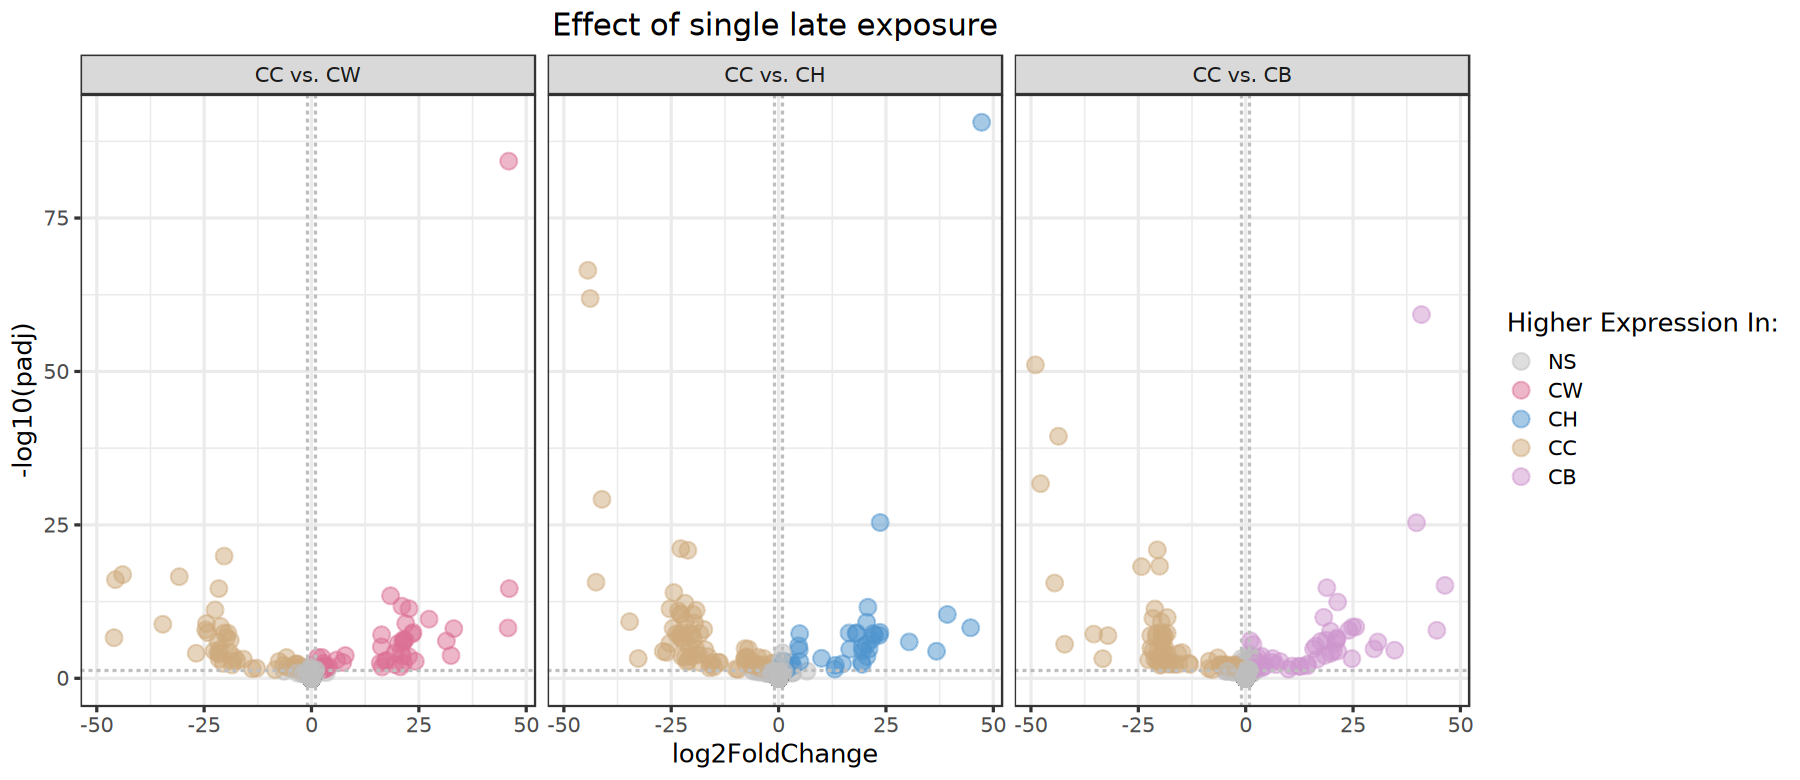

In [14]:
options(repr.plot.width=15, repr.plot.height=6.5)

# Specify the order for plots to follow Sophie's order
comp2$pair <- factor(comp2$pair, levels = c("CC vs. CW", "CC vs. CH", "CC vs. CB"))


comp2.plot <- ggplot(data = comp2,
                     aes(x = log2FoldChange,
                         y = -log10(padj),
                         col = DEG_group)) +
geom_point(size=4, alpha = 0.5) +
scale_color_manual(values = c("CH" = "steelblue3", "CW" = "palevioletred", "CC" = "burlywood3", "CB" = "plum3", "NS" = "grey")) +
# fold change threshold line
geom_vline(xintercept = c(-1, 1), 
           col = "gray",
           linetype = "dashed") +
# adjusted p-value line
geom_hline(yintercept = -log10(0.05),
           col = "gray",
           linetype = "dashed") +
facet_wrap(~pair) +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust=.5)) + 
labs(col = 'Higher Expression In:',
    title = 'Effect of single late exposure') +
guides(col = guide_legend(reverse = TRUE))

comp2.plot

^ slightly confusing though bc i'm using the same color scheme as plot 1, but the colors denote different phase 1 and phase 2 exposures - will need to fix going forward but I'm not sure that this is super informative, given all the comparisons I have

#### 3. Effect of timing of initial stress exposure

In [15]:
# combining dfs
comp3 <- rbind(deg_list$cw_wc, deg_list$ch_hc, deg_list$cb_bc)

# check things look okay
head(comp3)
tail(comp3)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC144621260,1.973312e+03,0.042496741,0.1401299,0.53018189,0.5959858,0.9216018,0.9937204,2495.69160,2092.46282,⋯,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527,WC vs. CW,NS
2,LOC144621269,2.477696e+03,0.026851276,0.2044691,1.21270710,0.2252418,0.7200792,0.9640417,52.27077,1648.11743,⋯,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403,WC vs. CW,NS
3,LOC111120925,1.301645e+02,-0.012254770,0.1871398,-0.60824955,0.5430220,0.9035456,0.9830011,66.52643,23.22715,⋯,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321,WC vs. CW,NS
4,Trnae-cuc-2,1.043799e-02,0.000000000,0.3577088,0.00000000,1.0000000,NA,0.9716568,0.00000,0.00000,⋯,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,WC vs. CW,NS
5,Trnae-cuc-3,3.559860e-02,0.000000000,0.3577088,0.00000000,1.0000000,NA,0.9716621,0.00000,0.00000,⋯,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,WC vs. CW,NS
6,LOC144621283,8.712697e+02,-0.006302105,0.1355830,-0.07716079,0.9384956,0.9979655,0.9941609,540.76486,870.51301,⋯,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524,WC vs. CW,NS


,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
87052,LOC111111213,11075.926433,-0.007119265,0.1110079,-0.1238798,0.9014104,1.0000000,0.9898290,11318.046933,9510.001136,⋯,13068.8259,7538.652,8573.462642,9327.9104,11735.12197,8842.716365,7014.32652,9198.50056,BC vs. CB,NS
87053,LOC111114497,184.293713,0.005820827,0.1418822,0.1217993,0.9030580,1.0000000,0.9868312,100.740026,120.175229,⋯,317.9308,115.823,50.481625,162.7459,236.60455,68.875429,118.90538,119.27962,BC vs. CB,NS
87054,LOC111114498,2778.215373,0.140113511,0.1390872,1.9334516,0.0531806,0.5062727,0.9885710,2457.676494,2850.879602,⋯,2709.2691,2059.414,2214.647585,2758.1149,3021.34737,2202.902833,2348.65397,2513.46879,BC vs. CB,NS
87055,LOC111112304,1110.683329,0.028471389,0.1066049,0.4846405,0.6279314,0.9785286,0.9899792,1218.384093,1188.623908,⋯,683.2395,1128.766,1080.680712,1278.4120,868.70986,878.717166,1363.59380,1162.70766,BC vs. CB,NS
87056,LOC144621306,9.898835,-0.014438124,0.1871220,-0.7299381,0.4654280,0.9365862,0.9679958,7.603021,28.276525,⋯,19.9486,0.000,2.804535,0.0000,15.07774,0.000000,0.00000,0.00000,BC vs. CB,NS
87057,LOC144621888,34.079249,0.006826786,0.1677762,0.2608225,0.7942294,0.9963451,0.9811297,3.801510,7.069131,⋯,9.9743,0.000,329.065407,250.5430,55.67166,7.776258,22.90838,19.34264,BC vs. CB,NS


In [16]:
comp3 <- comp3 %>%
# add phase 1 info for DEG
mutate(deg_p1 = case_when(
    str_starts(DEG_group, 'C') ~ 'Control',
    str_starts(DEG_group, 'W') ~ 'Warm',
    str_starts(DEG_group, 'H') ~ 'Hypoxic',
    str_starts(DEG_group, 'B') ~ 'Both',
    TRUE ~ 'NS')) %>%
# add phase 2 info for DEG
mutate(deg_p2 = case_when(
    str_ends(DEG_group, 'C') ~ 'Control',
    str_ends(DEG_group, 'W') ~ 'Warm',
    str_ends(DEG_group, 'H') ~ 'Hypoxic',
    str_ends(DEG_group, 'B') ~ 'Both',
    TRUE ~ 'NS'))

head(comp3)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48,pair,DEG_group,deg_p1,deg_p2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,LOC144621260,1.973312e+03,0.042496741,0.1401299,0.53018189,0.5959858,0.9216018,0.9937204,2495.69160,2092.46282,⋯,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527,WC vs. CW,NS,NS,NS
2,LOC144621269,2.477696e+03,0.026851276,0.2044691,1.21270710,0.2252418,0.7200792,0.9640417,52.27077,1648.11743,⋯,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403,WC vs. CW,NS,NS,NS
3,LOC111120925,1.301645e+02,-0.012254770,0.1871398,-0.60824955,0.5430220,0.9035456,0.9830011,66.52643,23.22715,⋯,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321,WC vs. CW,NS,NS,NS
4,Trnae-cuc-2,1.043799e-02,0.000000000,0.3577088,0.00000000,1.0000000,NA,0.9716568,0.00000,0.00000,⋯,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,WC vs. CW,NS,NS,NS
5,Trnae-cuc-3,3.559860e-02,0.000000000,0.3577088,0.00000000,1.0000000,NA,0.9716621,0.00000,0.00000,⋯,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,WC vs. CW,NS,NS,NS
6,LOC144621283,8.712697e+02,-0.006302105,0.1355830,-0.07716079,0.9384956,0.9979655,0.9941609,540.76486,870.51301,⋯,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524,WC vs. CW,NS,NS,NS


In [17]:
unique(comp3$pair)

[1] "WC vs. CW" "HC vs. CH" "BC vs. CB"

Warning message:
“Removed 1925 rows containing missing values or values outside the scale range
(`geom_point()`).”


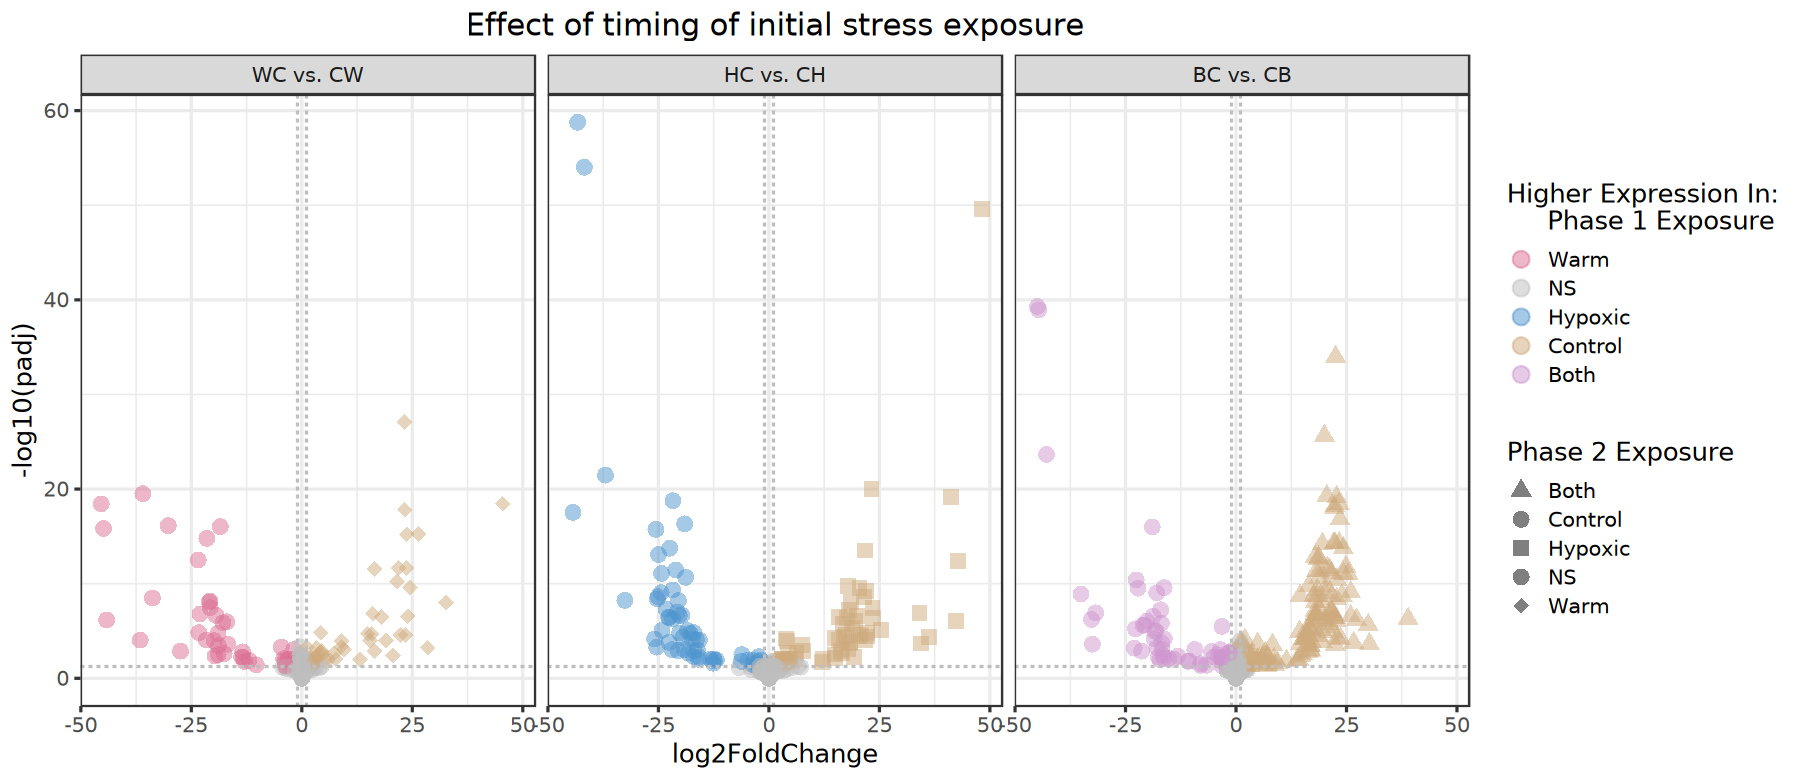

In [18]:
options(repr.plot.width=15, repr.plot.height=6.5)

# Specify the order for plots to follow Sophie's order
comp3$pair <- factor(comp3$pair, levels = c("WC vs. CW", "HC vs. CH", "BC vs. CB"))


comp3.plot <- ggplot(data = comp3,
                     aes(x = log2FoldChange,
                         y = -log10(padj),
                         col = deg_p1,
                        shape = deg_p2)) +
geom_point(size=4, alpha = 0.5) +
# select colors for phase 1
scale_color_manual(values = c("Hypoxic" = "steelblue3", 
                              "Warm" = "palevioletred", 
                              "Control" = "burlywood3", 
                              "Both" = "plum3", 
                              "NS" = "grey")) +
# select shapes for phase 2
scale_shape_manual(values = c(
    'Hypoxic' = 15,
    'Warm' = 18,
    'Control' = 16,
    'Both' = 17,
    'NS' = 16)) +
# fold change threshold line
geom_vline(xintercept = c(-1, 1), 
           col = "gray",
           linetype = "dashed") +
# adjusted p-value line
geom_hline(yintercept = -log10(0.05),
           col = "gray",
           linetype = "dashed") +
facet_wrap(~pair) +
theme_bw(base_size = 15) +
theme(plot.title = element_text(hjust=.5)) + 
labs(col = 'Higher Expression In:
     Phase 1 Exposure',
     shape = 'Phase 2 Exposure',
    title = 'Effect of timing of initial stress exposure') +
guides(col = guide_legend(reverse = TRUE, order = 1))

comp3.plot